## Import Dataset 

In [17]:
from datasets import load_dataset
import pandas as pd

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("THUIR/Qilin", "dqa")

print(ds)
print(ds.keys())

DatasetDict({
    train: Dataset({
        features: ['query', 'query_from_type', 'dqa_output', 'is_like_clk', 'is_onebox_trace_clk', 'is_content_clk', 'is_experience_clk', 'recent_clicked_note_idxs', 'ref_note_idx_list', 'session_idx', 'search_idx', 'user_idx', 'bm25_results', 'dpr_results', 'search_result_details_with_idx'],
        num_rows: 6972
    })
})
dict_keys(['train'])


In [18]:
df = ds["train"].to_pandas()

df.loc[0, "search_result_details_with_idx"]

array([{'click': 1, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 1059328, 'page_time': 17.593, 'position': 1, 'search_timestamp': 1732667595, 'share': 0},
       {'click': 0, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 32410, 'page_time': -1.0, 'position': 2, 'search_timestamp': 1732667595, 'share': 0},
       {'click': 1, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 1961579, 'page_time': 19.672, 'position': 3, 'search_timestamp': 1732667595, 'share': 0},
       {'click': 0, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 45278, 'page_time': -1.0, 'position': 4, 'search_timestamp': 1732667595, 'share': 0},
       {'click': 0, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 33243, 'page_time': -1.0, 'position': 5, 'search_timestamp': 1732667619, 'share': 0},
       {'click': 1, 'collect': 0, 'comment': 0, 'like': 0, 'note_idx': 1968318, 'page_time': 19.28, 'position': 7, 'search_timestamp': 1732667642, 'share': 0},
       {'click': 0, 'collect': 0, 'comment': 0,

## Converting the dataset to item-level observations

The dataset is structured such that each row represents a search event, and the results shown to the user are stored as a list in the column `search_result_details_with_idx`.

Each element in this list corresponds to a single item, including its position and whether it was clicked.

To analyze click behavior, we need one row per item. Therefore, we:

1. Expand the list so each item becomes its own row (`explode`)
2. Convert each item (stored as a dictionary) into separate columns

This results in a dataset where each row represents a single item shown to the user, which is required for click modeling.

In [19]:
# Flatten results: one row per shown item
result_df = df.explode("search_result_details_with_idx")

# Turn dictionaries into columns
result_df = pd.concat(
    [
        result_df.drop(columns=["search_result_details_with_idx"]),
        result_df["search_result_details_with_idx"].apply(pd.Series)
    ],
    axis=1
)

result_df.head()

,query,query_from_type,dqa_output,is_like_clk,is_onebox_trace_clk,is_content_clk,is_experience_clk,recent_clicked_note_idxs,ref_note_idx_list,session_idx,...,dpr_results,click,collect,comment,like,note_idx,page_time,position,search_timestamp,share
0,珠海长隆长隆秀一定要海洋馆吗,2.0,-1,-1.0,-1.0,-1.0,-1.0,"[1184038, 1184038, 1615342, 1432715, 1674717, ...",[],1851,...,"[[25037.0, 340.496337890625], [1625288.0, 340....",1.0,0.0,0.0,0.0,1059328.0,17.593,1.0,1.732668e+09,0.0
0,珠海长隆长隆秀一定要海洋馆吗,2.0,-1,-1.0,-1.0,-1.0,-1.0,"[1184038, 1184038, 1615342, 1432715, 1674717, ...",[],1851,...,"[[25037.0, 340.496337890625], [1625288.0, 340....",0.0,0.0,0.0,0.0,32410.0,-1.000,2.0,1.732668e+09,0.0
0,珠海长隆长隆秀一定要海洋馆吗,2.0,-1,-1.0,-1.0,-1.0,-1.0,"[1184038, 1184038, 1615342, 1432715, 1674717, ...",[],1851,...,"[[25037.0, 340.496337890625], [1625288.0, 340....",1.0,0.0,0.0,0.0,1961579.0,19.672,3.0,1.732668e+09,0.0
0,珠海长隆长隆秀一定要海洋馆吗,2.0,-1,-1.0,-1.0,-1.0,-1.0,"[1184038, 1184038, 1615342, 1432715, 1674717, ...",[],1851,...,"[[25037.0, 340.496337890625], [1625288.0, 340....",0.0,0.0,0.0,0.0,45278.0,-1.000,4.0,1.732668e+09,0.0
0,珠海长隆长隆秀一定要海洋馆吗,2.0,-1,-1.0,-1.0,-1.0,-1.0,"[1184038, 1184038, 1615342, 1432715, 1674717, ...",[],1851,...,"[[25037.0, 340.496337890625], [1625288.0, 340....",0.0,0.0,0.0,0.0,33243.0,-1.000,5.0,1.732668e+09,0.0


## Selecting relevant variables

We focus on variables required for modeling click behavior:

- `click`: whether the item was clicked (target variable)
- `position`: the rank at which the item was shown
- `session_idx`: identifies the user session
- `search_idx`: identifies the search within a session
- `note_idx`: identifies the item

Other variables are not included, as the focus is on modeling examination behavior rather than content relevance.

In [20]:
result_df = result_df[[
    "session_idx",
    "search_idx",
    "note_idx",
    "position",
    "click"
]]

result_df.head()

,session_idx,search_idx,note_idx,position,click
0,1851,4638,1059328.0,1.0,1.0
0,1851,4638,32410.0,2.0,0.0
0,1851,4638,1961579.0,3.0,1.0
0,1851,4638,45278.0,4.0,0.0
0,1851,4638,33243.0,5.0,0.0


In [41]:
print(result_df["position"].min())

0.0


## Representing the two-column layout

Although the dataset provides a one-dimensional position (`position`), the interface displays results in two columns.

To model this layout, we convert position into:

- `row`: vertical position
- `column`: left (0) or right (1)

This allows us to analyze click behavior in two dimensions instead of a single ranked list, which aligns with the goal of developing a two-dimensional click model.

### Position starts at 0?

In [94]:
result_df["row"] = result_df["position"] // 2
result_df["column"] = (result_df["position"] - 1) % 2

# result_df.head()
result_df[["position", "row", "column", "click"]].head()
# print(result_df["position"].min())

,position,row,column,click
0,1.0,0.0,0.0,1.0
0,2.0,1.0,1.0,0.0
0,3.0,1.0,0.0,1.0
0,4.0,2.0,1.0,0.0
0,5.0,2.0,0.0,0.0


## Observation: Row 0 inconsistency

In the first row (row = 0), the distribution across columns is highly imbalanced:

- column 0: 6933 observations  
- column 1: 9 observations  

This suggests that row 0 does not follow the standard two-column layout, unlike the rest of the data. As a result, the CTR for column 1 in this row is not meaningful.

### Question

Would it be appropriate to exclude row 0 from the analysis, given that the focus is on consistent two-column behavior?


In [88]:
result_df[result_df["row"] == 0]["column"].value_counts()
clean_df = result_df[result_df["row"] > 0]

### Is the rest of the dataset actually valid 2-column data?

In [89]:
balance = result_df.groupby(["row", "column"]).size().unstack(fill_value=0)
balance.head()


column,0.0,1.0
row,,
0.0,6933,9
1.0,6106,6923
2.0,4180,6018
3.0,3323,3803
4.0,2760,3199


In [90]:
balance["imbalance"] = abs(balance[0] - balance[1]) / (balance[0] + balance[1])
balance["imbalance"].describe()
balance[balance["imbalance"] > 0.5]

column,0.0,1.0,imbalance
row,,,
0.0,6933,9,0.997407
25.0,71,309,0.626316
82.0,7,2,0.555556
83.0,5,0,1.000000
86.0,5,1,0.666667
99.0,4,1,0.600000
109.0,1,4,0.600000
113.0,0,1,1.000000
116.0,1,4,0.600000


In [87]:
balance["total"] = balance[0] + balance[1]

filtered_balance = balance[balance["total"] > 50]
filtered_balance.sort_values("imbalance", ascending=False)

column,0.0,1.0,imbalance,total
row,,,,
0.0,6933,9,0.997407,6942
25.0,71,309,0.626316,380
2.0,4180,6018,0.180231,10198
28.0,52,73,0.168000,125
27.0,54,72,0.142857,126
32.0,45,55,0.100000,100
40.0,23,28,0.098039,51
31.0,51,42,0.096774,93
34.0,40,48,0.090909,88


Row 0 shows extreme imbalance across columns (6933 vs 9 // 0.997).  
Row 25 also shows noticeable imbalance (71 vs 309 // 0.62).  
Most other rows (with sufficient observations >50) are relatively balanced.

Only row 0 is removed in clean_df.

### CLick-Through Rate
	•	Left column (0): ~17.8% click rate
	•	Right column (1): ~20.9% click rate

This suggests:
	•	attention is not evenly distributed
	•	layout influences behavior

“Is there a column bias?”
“Is there a position decay over rows?”

Click-through rate decreases as row increases, indicating that items shown higher in the interface are more likely to be clicked. This reflects position bias, a well-established phenomenon in search systems.

Click-through rates differ between the two columns, indicating that horizontal layout influences user interaction. This suggests that users do not distribute attention evenly across columns.

In [99]:
CTR_column = clean_df.groupby("column")["click"].mean()
CTR_row = clean_df.groupby("row")["click"].mean()

CTR_column, CTR_row[:10]

(column
 0.0    0.177738
 1.0    0.209007
 Name: click, dtype: float64,
 row
 1.0     0.280605
 2.0     0.269955
 3.0     0.241791
 4.0     0.205739
 5.0     0.169129
 6.0     0.179629
 7.0     0.164740
 8.0     0.145946
 9.0     0.151452
 10.0    0.150591
 Name: click, dtype: float64)

In [100]:
pivot = clean_df.pivot_table(
    index="row",
    columns="column",
    values="click",
    aggfunc="mean"
)

pivot.head(10)

column,0.0,1.0
row,,
1.0,0.217982,0.335837
2.0,0.256699,0.279163
3.0,0.225399,0.256114
4.0,0.188406,0.220694
5.0,0.180451,0.159273
6.0,0.174544,0.184177
7.0,0.167315,0.162431
8.0,0.141433,0.150145
9.0,0.138593,0.163636


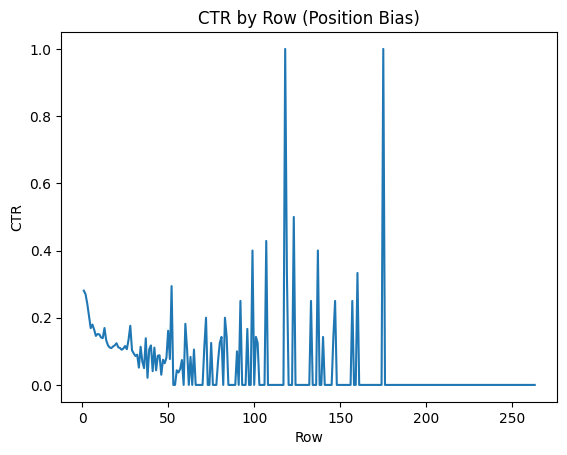

In [101]:
import matplotlib.pyplot as plt

CTR_row.plot()
plt.xlabel("Row")
plt.ylabel("CTR")
plt.title("CTR by Row (Position Bias)")
plt.show()

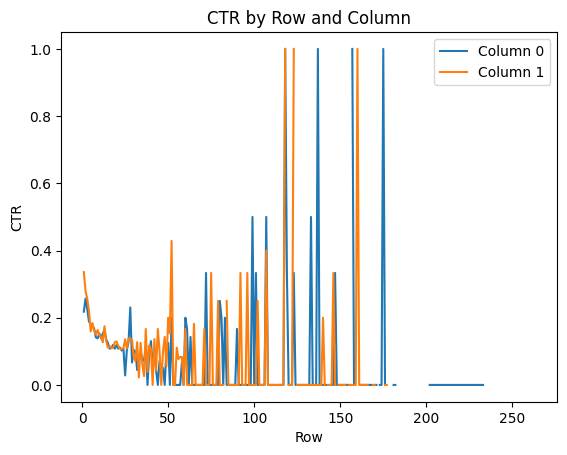

In [103]:
pivot.plot()
plt.xlabel("Row")
plt.ylabel("CTR")
plt.title("CTR by Row and Column")
plt.legend(["Column 0", "Column 1"])
plt.show()

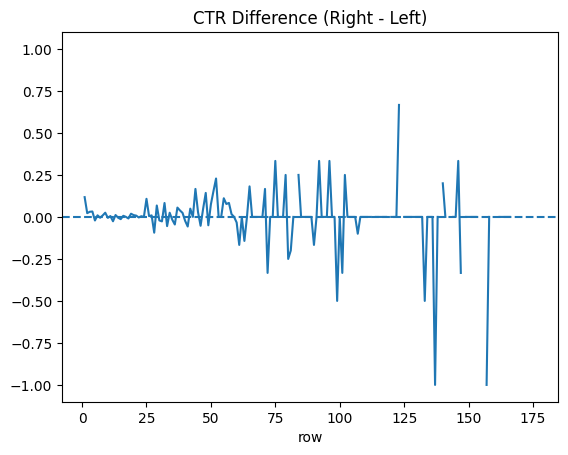

In [ ]:
pivot["diff"] = pivot[1.0] - pivot[0.0]
pivot["diff"].head(10)


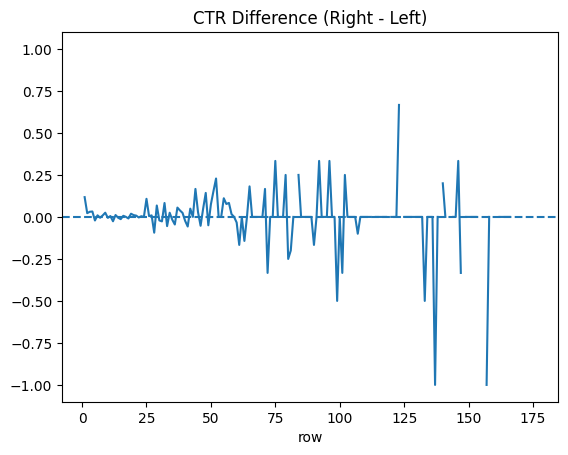

In [106]:
pivot["diff"].plot()
plt.axhline(0, linestyle="--")
plt.title("CTR Difference (Right - Left)")
plt.show()

In [111]:
import statsmodels.api as sm

X = clean_df[["row", "column"]]
X = sm.add_constant(X)
y = clean_df["click"]

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.482579
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  click   No. Observations:                80419
Model:                          Logit   Df Residuals:                    80416
Method:                           MLE   Df Model:                            2
Date:                Wed, 01 Apr 2026   Pseudo R-squ.:                 0.02035
Time:                        23:03:02   Log-Likelihood:                -38809.
converged:                       True   LL-Null:                       -39615.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1807      0.016    -71.653      0.000      -1.213      -1.148
row           -0.0480      0.